# Task 1 — Revised Analysis
**Reference:** Antonio, N., Almeida, A., & Nunes, L. (2019). *Hotel booking demand datasets.*
Data in Brief, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126

---

## What This Revision Does

The original Task 1 was produced from data inspection alone.
This revision cross-references every finding against the published dataset paper.
All changes are explicitly labelled:

| Label | Meaning |
|---|---|
| ✅ UNCHANGED | Confirmed by paper — no correction needed |
| 🔄 REVISED | Original interpretation was wrong or incomplete |
| 🆕 NEW | Risk or finding not in the original analysis |

### Summary of Changes Driven by the Paper

| # | Variable / Topic | Original | Revised | Why |
|---|---|---|---|---|
| 1 | `agent` NULLs | Missing data (MAR, 13.7%) → impute | **Valid category "no agent"** — do NOT impute | Paper §2: *"NULL should not be considered a missing value, but rather 'not applicable'"* |
| 2 | `company` NULLs | Missing data (94%) → drop column | **Valid category "no company"** — encode as `'None'` | Same paper statement |
| 3 | `country` | Safe feature | 🆕 **Indirect temporal risk** | Paper §2: *"hotels often don't know nationality until check-in"* |
| 4 | `booking_changes` | Suspected indirect risk | ✅ Confirmed indirect risk | Paper Table 1: *"from booking entry until check-in OR cancellation"* |
| 5 | `deposit_type` | Not assessed | ✅ Confirmed safe | Paper Table 1: *"based on payments before arrival or cancellation date"* |
| 6 | `days_in_waiting_list` | Suspected indirect risk | ✅ Confirmed safe | Paper Table 1: known at confirmation, before any outcome |
| 7 | `previous_cancellations/bookings` | Simple counts | 🔄 0 has dual meaning: zero history **or** no customer profile | Paper Table 1: *"In case there was no customer profile, value is set to 0"* |
| 8 | `meal='Undefined'` | Vague/unknown | ✅ Confirmed ≡ SC (no meal) | Paper Table 1 explicitly equates them |
| 9 | General leakage design | Conservative — many indirect risks | Most features are **genuinely pre-outcome** | Paper §1: values extracted from change log at day-prior-to-arrival to prevent leakage |


## 0. Imports & Setup

In [1]:
import warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 220)

DATA_PATH  = Path("hotel_bookings.csv")
OUTPUT_DIR = Path("outputs/task1_revised")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
original_ncols = df.shape[1]
print(f"Loaded: {df.shape[0]:,} rows x {original_ncols} columns")


Loaded: 119,390 rows x 32 columns


## 1. Schema — Revised with Paper Source Annotations

The paper (Table 1) documents the exact database source for each variable:
- **BO** = Booking table
- **BL** = Booking Log (change log, timestamped at day-prior-to-arrival)
- **TR** = Transactions table
- **C** = Customer profile table
- **MS / ML / DC / NT** = related dimension tables

This source information is **critical** for assessing leakage risk.


In [2]:
SCHEMA = [
    # column, paper_type, source, risk_level, status, note
    ("hotel",                          "cat",   "BO,BL",       "safe",     "✅ UNCHANGED", "Resort/City — booking attribute"),
    ("is_canceled",                    "bin",   "BO",          "outcome",  "✅ UNCHANGED", "TARGET — 1=cancelled"),
    ("lead_time",                      "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Days from entry to arrival; pre-outcome"),
    ("arrival_date_year",              "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Arrival year"),
    ("arrival_date_month",             "cat",   "BO,BL",       "safe",     "✅ UNCHANGED", "Arrival month"),
    ("arrival_date_week_number",       "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "ISO week number"),
    ("arrival_date_day_of_month",      "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Day of month"),
    ("stays_in_weekend_nights",        "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Counted from total nights"),
    ("stays_in_week_nights",           "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Counted from total nights"),
    ("adults",                         "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Number of adults"),
    ("children",                       "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Payable + non-payable children; 4 genuinely missing"),
    ("babies",                         "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Number of babies"),
    ("meal",                           "cat",   "BO,BL,ML",    "safe",     "✅ UNCHANGED", "Undefined ≡ SC per paper Table 1"),
    ("country",                        "cat",   "BO,BL,NT",    "indirect", "🆕 NEW RISK",  "Nationality may be unknown/corrected at check-in (paper caution)"),
    ("market_segment",                 "cat",   "BO,BL,MS",    "safe",     "✅ UNCHANGED", "Booking segment"),
    ("distribution_channel",           "cat",   "BO,BL,DC",    "safe",     "✅ UNCHANGED", "Distribution channel"),
    ("is_repeated_guest",              "bin",   "BO,BL,C",     "safe",     "✅ UNCHANGED", "Profile creation date vs booking date checked"),
    ("previous_cancellations",         "int",   "BO,BL",       "safe",     "🔄 REVISED",   "0 = zero history OR no customer profile (dual meaning)"),
    ("previous_bookings_not_canceled", "int",   "BO,BL",       "safe",     "🔄 REVISED",   "0 = zero history OR no customer profile (dual meaning)"),
    ("reserved_room_type",             "cat",   "BO,BL",       "safe",     "✅ UNCHANGED", "Room type at booking time"),
    ("assigned_room_type",             "cat",   "BO,BL",       "indirect", "✅ UNCHANGED", "May differ due to ops or customer request; confirmed indirect"),
    ("booking_changes",                "int",   "BO,BL",       "indirect", "✅ UNCHANGED", "Confirmed: accumulates until check-in OR cancellation"),
    ("deposit_type",                   "cat",   "BO,TR",       "safe",     "✅ UNCHANGED", "Confirmed safe: computed from payments before arrival/cancellation"),
    ("agent",                          "cat",   "BO,BL",       "safe",     "🔄 REVISED",   "NULL = 'no agent' — explicit category, NOT missing data"),
    ("company",                        "cat",   "BO,BL",       "safe",     "🔄 REVISED",   "NULL = 'no company' — explicit category, NOT missing data"),
    ("days_in_waiting_list",           "int",   "BO",          "safe",     "🔄 REVISED",   "Confirmed safe: known at confirmation, before outcome"),
    ("customer_type",                  "cat",   "BO,BL",       "safe",     "✅ UNCHANGED", "Transient/Contract/Group/Transient-Party"),
    ("adr",                            "float", "BO,BL,TR",    "indirect", "✅ UNCHANGED", "Transaction-based; may update post-booking"),
    ("required_car_parking_spaces",    "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Customer preference"),
    ("total_of_special_requests",      "int",   "BO,BL",       "safe",     "✅ UNCHANGED", "Count of special requests"),
    ("reservation_status",             "cat",   "BO",          "direct",   "✅ UNCHANGED", "DIRECT LEAKAGE — must drop"),
    ("reservation_status_date",        "date",  "BO",          "direct",   "✅ UNCHANGED", "DIRECT LEAKAGE — must drop"),
]

schema_df = pd.DataFrame(SCHEMA, columns=[
    "column","paper_type","source","risk_level","status","note"])

print("Variables by risk level:")
print(schema_df["risk_level"].value_counts().to_string())
print()
print("Revised / New variables:")
for _, r in schema_df[schema_df["status"].str.startswith(("🔄","🆕"))].iterrows():
    print(f"  {r['column']:35s} [{r['status']}]  {r['note']}")


Variables by risk level:
risk_level
safe        25
indirect     4
direct       2
outcome      1

Revised / New variables:
  country                             [🆕 NEW RISK]  Nationality may be unknown/corrected at check-in (paper caution)
  previous_cancellations              [🔄 REVISED]  0 = zero history OR no customer profile (dual meaning)
  previous_bookings_not_canceled      [🔄 REVISED]  0 = zero history OR no customer profile (dual meaning)
  agent                               [🔄 REVISED]  NULL = 'no agent' — explicit category, NOT missing data
  company                             [🔄 REVISED]  NULL = 'no company' — explicit category, NOT missing data
  days_in_waiting_list                [🔄 REVISED]  Confirmed safe: known at confirmation, before outcome


In [3]:
schema_df

,column,paper_type,source,risk_level,status,note
0,hotel,cat,"BO,BL",safe,✅ UNCHANGED,Resort/City — booking attribute
1,is_canceled,bin,BO,outcome,✅ UNCHANGED,TARGET — 1=cancelled
2,lead_time,int,"BO,BL",safe,✅ UNCHANGED,Days from entry to arrival; pre-outcome
3,arrival_date_year,int,"BO,BL",safe,✅ UNCHANGED,Arrival year
4,arrival_date_month,cat,"BO,BL",safe,✅ UNCHANGED,Arrival month
5,arrival_date_week_number,int,"BO,BL",safe,✅ UNCHANGED,ISO week number
6,arrival_date_day_of_month,int,"BO,BL",safe,✅ UNCHANGED,Day of month
7,stays_in_weekend_nights,int,"BO,BL",safe,✅ UNCHANGED,Counted from total nights
8,stays_in_week_nights,int,"BO,BL",safe,✅ UNCHANGED,Counted from total nights
9,adults,int,"BO,BL",safe,✅ UNCHANGED,Number of adults


## 2. Missing Value Assessment — Revised

### 🔄 MAJOR REVISION: `agent` and `company` NULLs are NOT missing data

**Original Task 1 finding:** `agent` (13.7% null) and `company` (94.3% null) classified
as Missing At Random (MAR); `agent` flagged for imputation, `company` flagged for dropping.

**Paper §2 (p.45) — verbatim:**
> *"The PMS assured no missing data exists in its database tables. However, in some
> categorical variables like Agent or Company, 'NULL' is presented as one of the
> categories. This should not be considered a missing value, but rather as
> 'not applicable'. For example, if a booking 'Agent' is defined as 'NULL' it means
> that the booking did not come from a travel agent."*

**Consequence:** The entire imputation strategy for these two columns was wrong.
They have complete data. NULL is a meaningful, informative category.


In [4]:
# What pandas sees as NaN
raw_null = df.isnull().sum()
raw_null = raw_null[raw_null > 0].reset_index()
raw_null.columns = ["column", "n_null"]
raw_null["pct_null"] = (raw_null["n_null"] / len(df) * 100).round(3)
print("All columns with pandas NaN:")
print(raw_null.to_string(index=False))
print()
print("=" * 60)
print("REVISED CLASSIFICATION:")
print()
print("Genuinely missing (require imputation):")
print(f"  children : {df['children'].isna().sum():,} rows  →  fill with 0 (entry omission)")
print(f"  country  : {df['country'].isna().sum():,} rows  →  fill with 'Unknown'")
print()
print("NOT missing — structural 'None' category (NO imputation):")
print(f"  agent    : {df['agent'].isna().sum():,} nulls  →  encode NULL as category 'None' (no travel agent)")
print(f"  company  : {df['company'].isna().sum():,} nulls  →  encode NULL as category 'None' (no company account)")


All columns with pandas NaN:
  column  n_null  pct_null
children       4     0.003
 country     488     0.409
   agent   16340    13.686
 company  112593    94.307

REVISED CLASSIFICATION:

Genuinely missing (require imputation):
  children : 4 rows  →  fill with 0 (entry omission)
  country  : 488 rows  →  fill with 'Unknown'

NOT missing — structural 'None' category (NO imputation):
  agent    : 16,340 nulls  →  encode NULL as category 'None' (no travel agent)
  company  : 112,593 nulls  →  encode NULL as category 'None' (no company account)


In [5]:
# Prove agent/company NULLs are structurally determined (not random)
print("agent NULL rate by market_segment:")
print(df.groupby("market_segment")["agent"]
      .apply(lambda s: f"{s.isna().mean():.1%}").to_string())
print()
print("company NULL rate by market_segment:")
print(df.groupby("market_segment")["company"]
      .apply(lambda s: f"{s.isna().mean():.1%}").to_string())
print()
print("Interpretation: NULL rates are near-deterministic by channel.")
print("  Online TA -> agent NULL ~0%  (always booked through agent)")
print("  Direct    -> agent NULL ~48% (often no agent)")
print("This is business structure, not randomness. No imputation is appropriate.")


agent NULL rate by market_segment:
market_segment
Aviation          89.5%
Complementary     86.1%
Corporate         86.8%
Direct            47.7%
Groups            20.9%
Offline TA/TO      1.6%
Online TA          0.6%
Undefined        100.0%

company NULL rate by market_segment:
market_segment
Aviation          10.5%
Complementary     57.9%
Corporate         15.6%
Direct            98.3%
Groups            93.0%
Offline TA/TO     99.6%
Online TA         99.8%
Undefined        100.0%

Interpretation: NULL rates are near-deterministic by channel.
  Online TA -> agent NULL ~0%  (always booked through agent)
  Direct    -> agent NULL ~48% (often no agent)
This is business structure, not randomness. No imputation is appropriate.


### 🔄 REVISED: `previous_cancellations` and `previous_bookings_not_canceled`

**Paper Table 1:**
> *"In case there was no customer profile associated with the booking, the value is set to 0."*

**Consequence:** A value of 0 could mean:
- (a) Guest has a profile but zero prior events, OR
- (b) No customer profile exists at all

These two cases have different meanings. We must create a `has_customer_profile` flag
to disambiguate. Originally this nuance was missed.


In [6]:
# Demonstrate dual meaning of 0
df["has_customer_profile"] = (
    (df["is_repeated_guest"] == 1) |
    (df["previous_cancellations"] > 0) |
    (df["previous_bookings_not_canceled"] > 0)
).astype(int)

print("has_customer_profile distribution:")
print(df["has_customer_profile"].value_counts().to_string())
print()
print("Cancellation rate by profile availability:")
print(df.groupby("has_customer_profile")["is_canceled"].mean().round(4).to_string())
print()
print("Rows where all three 'history' fields = 0 (ambiguous):",
      ((df["is_repeated_guest"]==0) &
       (df["previous_cancellations"]==0) &
       (df["previous_bookings_not_canceled"]==0)).sum())


has_customer_profile distribution:
has_customer_profile
0    109343
1     10047

Cancellation rate by profile availability:
has_customer_profile
0    0.3492
1    0.6016

Rows where all three 'history' fields = 0 (ambiguous): 109343


## 3. Data Quality Checks — Revised

In [7]:
print("3a. Exact duplicates: {:,}  ({:.2%})  ✅ UNCHANGED".format(
    df.duplicated().sum(), df.duplicated().mean()))
print()

zero_g = df[(df["adults"]==0) & (df["children"].fillna(0)==0) & (df["babies"]==0)]
print(f"3b. Zero-guest bookings: {len(zero_g):,}  ✅ UNCHANGED — physically impossible")
print()

zero_n = df[(df["stays_in_weekend_nights"]+df["stays_in_week_nights"]==0)&(df["is_canceled"]==0)]
print(f"3c. Non-cancelled zero-night stays: {len(zero_n):,}  ✅ UNCHANGED")
print()

print(f"3d. Negative ADR: {(df['adr']<0).sum():,}  ✅ UNCHANGED — clip to 0")
print(f"    ADR > 5000  : {(df['adr']>5000).sum():,}  ✅ UNCHANGED — cap at 99.9th pct")
print()

n_undef = (df["meal"]=="Undefined").sum()
print(f"3e. meal='Undefined': {n_undef:,}  ✅ CONFIRMED by paper — equals SC (no meal package)")
print()

print("3f. 🔄 REVISED — agent/company NULLs REMOVED from quality issue list.")
print("    They are valid categories per paper, not data errors.")
print()

cross = pd.crosstab(df["reservation_status"], df["is_canceled"])
print("3g. reservation_status vs is_canceled cross-tab (leakage):")
print(cross.to_string())
print("    ✅ UNCHANGED — perfect 1:1 mapping confirmed")


3a. Exact duplicates: 31,994  (26.80%)  ✅ UNCHANGED

3b. Zero-guest bookings: 180  ✅ UNCHANGED — physically impossible

3c. Non-cancelled zero-night stays: 680  ✅ UNCHANGED

3d. Negative ADR: 1  ✅ UNCHANGED — clip to 0
    ADR > 5000  : 1  ✅ UNCHANGED — cap at 99.9th pct

3e. meal='Undefined': 1,169  ✅ CONFIRMED by paper — equals SC (no meal package)

3f. 🔄 REVISED — agent/company NULLs REMOVED from quality issue list.
    They are valid categories per paper, not data errors.

3g. reservation_status vs is_canceled cross-tab (leakage):
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207
    ✅ UNCHANGED — perfect 1:1 mapping confirmed


## 4. Leakage & Risk Assessment — Revised

### Critical paper statement on anti-leakage design (p.42):

> *"One of the most important properties in data for prediction models is not to promote
> leakage of future information. In order to prevent this from happening, the timestamp
> of the target variable must occur after the input variables' timestamp. Thus, instead of
> directly extracting variables from the bookings database table, when available, the
> variables' values were extracted from the **bookings change log, with a timestamp
> relative to the day prior to arrival date**."*

This means the dataset was **deliberately engineered to be anti-leakage** for most features.
Our original broad indirect-risk flags were overly conservative for features sourced
purely from BO/BL tables.


In [8]:
LEAKAGE = [
    # variable, original_flag, revised_flag, paper_evidence, action
    ("reservation_status",
     "DIRECT LEAKAGE",
     "DIRECT LEAKAGE ✅ UNCHANGED",
     "Outcome variable — Canceled/Check-Out/No-Show maps 1:1 to is_canceled",
     "DROP before any split"),

    ("reservation_status_date",
     "DIRECT LEAKAGE",
     "DIRECT LEAKAGE ✅ UNCHANGED",
     "Date of outcome — post-resolution; not available at prediction time",
     "DROP before any split"),

    ("booking_changes",
     "INDIRECT RISK (suspected)",
     "INDIRECT RISK ✅ CONFIRMED",
     "Paper Table 1: 'from booking entry until check-in OR cancellation' — "
     "for cancelled bookings accumulates up to cancellation moment",
     "Retain; monitor importance; note distributional shift is partly artefactual"),

    ("assigned_room_type",
     "INDIRECT RISK (suspected)",
     "INDIRECT RISK ✅ CONFIRMED (partially mitigated)",
     "Paper: 'differs due to hotel ops or customer request'. "
     "BL timestamp at day-prior means preliminary assignment exists. "
     "Risk is real but weaker than originally stated.",
     "Retain with caution"),

    ("adr",
     "INDIRECT RISK (suspected)",
     "INDIRECT RISK ✅ CONFIRMED",
     "Paper: sourced from BO, BL and TR (Transactions). "
     "Transaction-based calculation may update post-booking.",
     "Retain; monitor distribution by cancellation status"),

    ("country",
     "SAFE — not flagged",
     "🆕 NEW INDIRECT RISK",
     "Paper §2: 'hotels often don't know correct nationality until check-in'. "
     "Cancelled bookings never reach check-in → nationality may be inaccurate/imputed.",
     "Retain but flag; run ablation study to assess artefactual signal"),

    ("agent",
     "HIGH CARDINALITY + MAR missingness risk",
     "🔄 REVISED — SAFE CATEGORICAL",
     "Paper: NULL = 'no travel agent' — a valid category, not missing data. "
     "Not a post-hoc variable.",
     "Encode NULL as 'None' string; OHE or frequency-group"),

    ("company",
     "CRITICAL MISSINGNESS (94%) + drop recommended",
     "🔄 REVISED — SAFE CATEGORICAL (mostly 'None')",
     "Paper: NULL = 'no company account'. Not missing. Not post-hoc. "
     "94% are 'no company' bookings — legitimate market composition.",
     "Encode NULL as 'None'; has_company flag captures binary signal"),

    ("deposit_type",
     "Not assessed",
     "✅ CONFIRMED SAFE",
     "Paper Table 1: 'based on payments before booking arrival or cancellation date'. "
     "Explicitly pre-outcome by construction.",
     "Retain as-is; strong predictor"),

    ("days_in_waiting_list",
     "INDIRECT RISK (suspected)",
     "🔄 REVISED — SAFE",
     "Paper Table 1: 'days in waiting list before confirmed to customer'. "
     "Known at confirmation, well before arrival or cancellation.",
     "Retain as-is; no risk"),
]

for row in LEAKAGE:
    var, orig, revised, evidence, action = row
    icon = "🔴" if "DIRECT" in revised else "🟠" if "INDIRECT" in revised else            "🆕" if "NEW" in revised else "🔄" if "REVISED" in revised else "🟢"
    print(f"{icon}  {var}")
    print(f"   Original : {orig}")
    print(f"   Revised  : {revised}")
    print(f"   Evidence : {evidence}")
    print(f"   Action   : {action}")
    print()


🔴  reservation_status
   Original : DIRECT LEAKAGE
   Revised  : DIRECT LEAKAGE ✅ UNCHANGED
   Evidence : Outcome variable — Canceled/Check-Out/No-Show maps 1:1 to is_canceled
   Action   : DROP before any split

🔴  reservation_status_date
   Original : DIRECT LEAKAGE
   Revised  : DIRECT LEAKAGE ✅ UNCHANGED
   Evidence : Date of outcome — post-resolution; not available at prediction time
   Action   : DROP before any split

🔴  booking_changes
   Original : INDIRECT RISK (suspected)
   Revised  : INDIRECT RISK ✅ CONFIRMED
   Evidence : Paper Table 1: 'from booking entry until check-in OR cancellation' — for cancelled bookings accumulates up to cancellation moment
   Action   : Retain; monitor importance; note distributional shift is partly artefactual

🔴  assigned_room_type
   Original : INDIRECT RISK (suspected)
   Revised  : INDIRECT RISK ✅ CONFIRMED (partially mitigated)
   Evidence : Paper: 'differs due to hotel ops or customer request'. BL timestamp at day-prior means preliminary 

## 5. Preprocessing Plan — Revised

In [9]:
PLAN = [
    # step, original, revised, change
    ("Step 1 — Drop leakage columns",
     "Drop reservation_status, reservation_status_date",
     "Same. ✅ UNCHANGED",
     "✅"),

    ("Step 2 — company",
     "Drop column (94% missing); create has_company flag",
     "🔄 REVISED: NULLs are 'no company' category — NOT missing. "
     "Fill NaN → string 'None' before encoding. "
     "has_company binary flag still useful as a compact feature.",
     "🔄"),

    ("Step 3 — agent",
     "Create has_agent flag; impute NULLs with sentinel -1",
     "🔄 REVISED: NULLs are 'no agent' category — NOT missing. "
     "Fill NaN → string 'None' before encoding. No sentinel imputation needed.",
     "🔄"),

    ("Step 4 — Fix impossible values",
     "Zero guests → drop; ADR<0 → clip; duplicates → remove",
     "Same. ✅ UNCHANGED",
     "✅"),

    ("Step 5 — Impute genuinely missing",
     "children→0, country→mode, agent→sentinel, company→dropped",
     "🔄 REVISED: Only children→0 and country→'Unknown'. "
     "agent and company are NOT missing — remove from imputation list entirely.",
     "🔄"),

    ("Step 6 — Feature engineering",
     "total_nights, total_guests, cancel_rate_history, room_changed, "
     "weekend_ratio, arrival_month_num, has_agent, has_company",
     "🔄 REVISED: Add has_customer_profile flag to disambiguate 0-meaning "
     "in previous_cancellations / previous_bookings_not_canceled. "
     "All other engineered features unchanged.",
     "🔄"),

    ("Step 7 — Encode categoricals",
     "OHE low-cardinality; frequency-group country/agent; impute before encode",
     "🔄 REVISED: For agent and company, rename NaN → 'None' string BEFORE OHE. "
     "'None' is a valid category level, not to be dropped or imputed. "
     "All other encoding unchanged.",
     "🔄"),

    ("Step 8 — Scale numerics",
     "StandardScaler inside Pipeline",
     "✅ UNCHANGED",
     "✅"),

    ("Step 9 — Train/test split",
     "Chronological 80/20 (year→week→day sort)",
     "✅ UNCHANGED — temporal split is mandatory",
     "✅"),

    ("Step 10 — Cross-validation",
     "StratifiedKFold(5) on training set only",
     "✅ UNCHANGED",
     "✅"),

    ("Step 11 — country risk mitigation [NEW]",
     "Not in original plan",
     "🆕 NEW: Flag country as indirect temporal risk in documentation. "
     "Run an ablation (with vs. without country) to quantify artefactual signal. "
     "Do not drop — signal is real — but be cautious interpreting country importance.",
     "🆕"),

    ("Step 12 — Evaluation metrics",
     "ROC-AUC, PR-AUC, F1-macro",
     "✅ UNCHANGED",
     "✅"),
]

for step, original, revised, flag in PLAN:
    icon = {"✅": "✅", "🔄": "🔄", "🆕": "🆕"}.get(flag, "")
    print(f"{icon} {step}")
    if flag != "✅":
        print(f"   WAS: {original}")
        print(f"   NOW: {revised}")
    else:
        print(f"   {revised}")
    print()


✅ Step 1 — Drop leakage columns
   Same. ✅ UNCHANGED

🔄 Step 2 — company
   WAS: Drop column (94% missing); create has_company flag
   NOW: 🔄 REVISED: NULLs are 'no company' category — NOT missing. Fill NaN → string 'None' before encoding. has_company binary flag still useful as a compact feature.

🔄 Step 3 — agent
   WAS: Create has_agent flag; impute NULLs with sentinel -1
   NOW: 🔄 REVISED: NULLs are 'no agent' category — NOT missing. Fill NaN → string 'None' before encoding. No sentinel imputation needed.

✅ Step 4 — Fix impossible values
   Same. ✅ UNCHANGED

🔄 Step 5 — Impute genuinely missing
   WAS: children→0, country→mode, agent→sentinel, company→dropped
   NOW: 🔄 REVISED: Only children→0 and country→'Unknown'. agent and company are NOT missing — remove from imputation list entirely.

🔄 Step 6 — Feature engineering
   WAS: total_nights, total_guests, cancel_rate_history, room_changed, weekend_ratio, arrival_month_num, has_agent, has_company
   NOW: 🔄 REVISED: Add has_customer

## 6. Visualisations Supporting Revisions

### 6.1 agent/company NULLs — structural, not random

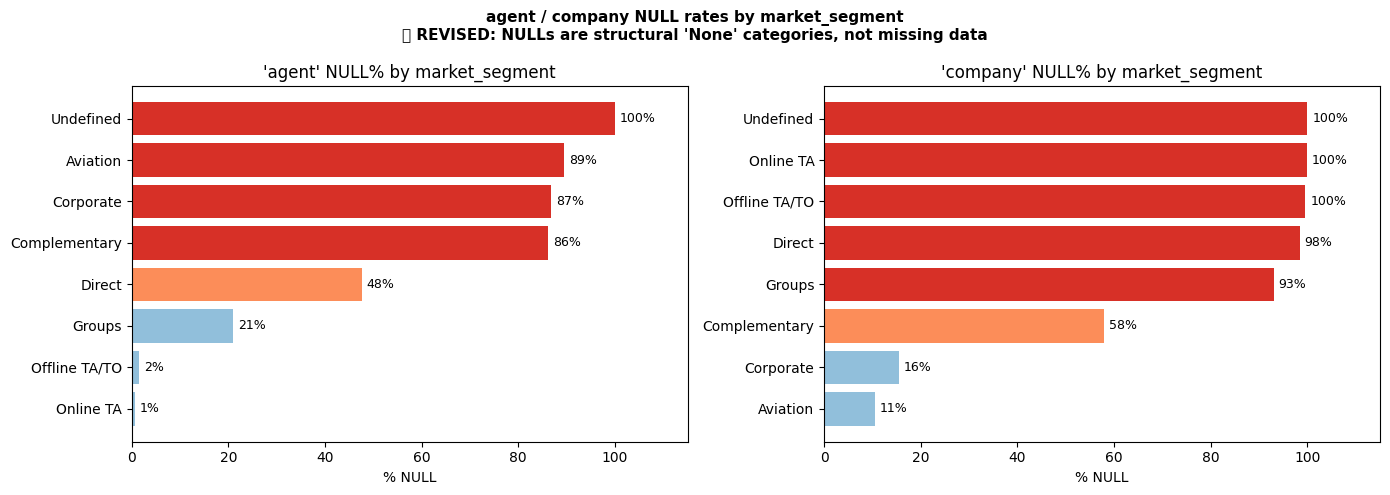

Near-deterministic by channel = domain structure, not data quality issue.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "agent / company NULL rates by market_segment\n"
    "🔄 REVISED: NULLs are structural 'None' categories, not missing data",
    fontsize=11, fontweight="bold")

for ax, col in zip(axes, ["agent", "company"]):
    pct = (df.groupby("market_segment")[col]
             .apply(lambda s: s.isna().mean() * 100)
             .sort_values())
    colors = ["#d73027" if v > 80 else "#fc8d59" if v > 40 else "#91bfdb" for v in pct]
    ax.barh(pct.index, pct.values, color=colors)
    ax.set_xlabel("% NULL")
    ax.set_title(f"'{col}' NULL% by market_segment")
    ax.set_xlim(0, 115)
    for i, v in enumerate(pct.values):
        ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "agent_company_structural_nulls.png", dpi=150, bbox_inches="tight")
plt.show()
print("Near-deterministic by channel = domain structure, not data quality issue.")


### 6.2 'None' agent IS informative — confirms it's a valid category

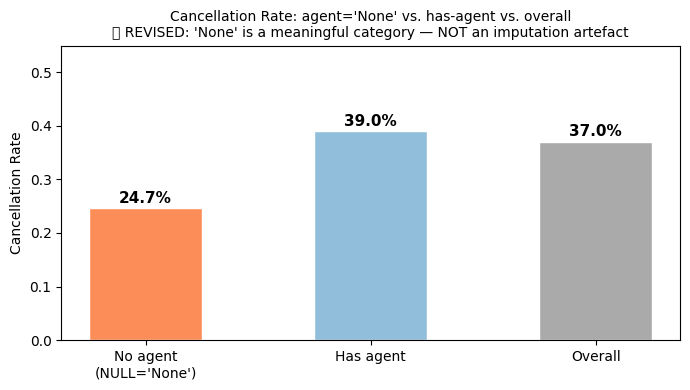

No-agent cancel rate: 24.7%  |  Has-agent: 39.0%  |  Δ = 14.3%
Substantial difference → 'None' carries real predictive signal.


In [11]:
df["agent_cat"] = df["agent"].fillna("None").astype(str)
cr_none  = df.loc[df["agent_cat"]=="None",  "is_canceled"].mean()
cr_agent = df.loc[df["agent_cat"]!="None",  "is_canceled"].mean()
cr_all   = df["is_canceled"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ["No agent\n(NULL='None')", "Has agent", "Overall"],
    [cr_none, cr_agent, cr_all],
    color=["#fc8d59", "#91bfdb", "#aaaaaa"], edgecolor="white", width=0.5)
ax.set_ylabel("Cancellation Rate")
ax.set_title(
    "Cancellation Rate: agent='None' vs. has-agent vs. overall\n"
    "🔄 REVISED: 'None' is a meaningful category — NOT an imputation artefact",
    fontsize=10)
ax.set_ylim(0, 0.55)
for bar, v in zip(bars, [cr_none, cr_agent, cr_all]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.1%}",
            ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "agent_none_informative.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"No-agent cancel rate: {cr_none:.1%}  |  Has-agent: {cr_agent:.1%}  |  Δ = {abs(cr_none-cr_agent):.1%}")
print("Substantial difference → 'None' carries real predictive signal.")


### 6.3 🆕 country — new indirect risk (nationality unknown until check-in)

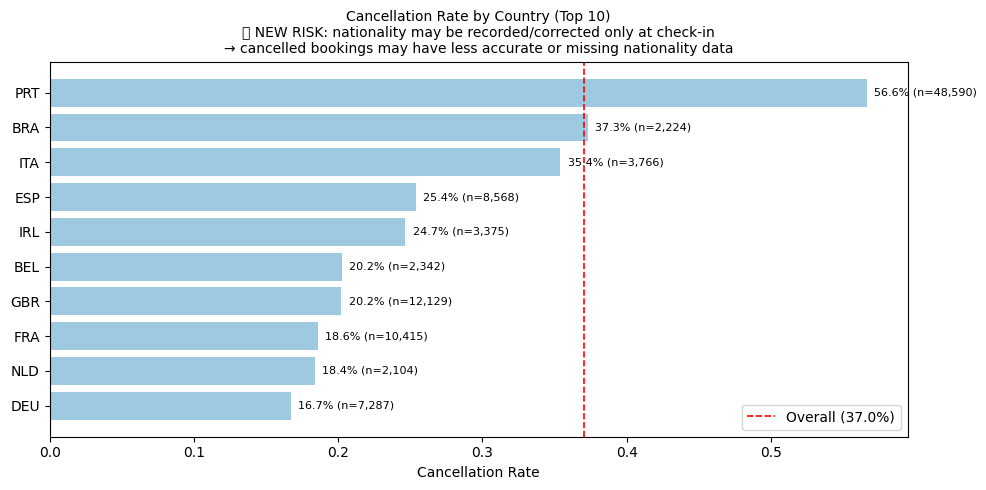

In [12]:
top10 = df["country"].value_counts().head(10).index
cdata = (df[df["country"].isin(top10)]
           .groupby("country")["is_canceled"]
           .agg(["mean","count"]).reset_index()
           .sort_values("mean", ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cdata["country"], cdata["mean"], color="#9ecae1")
ax.axvline(df["is_canceled"].mean(), color="red", linestyle="--",
           linewidth=1.2, label=f"Overall ({df['is_canceled'].mean():.1%})")
ax.set_xlabel("Cancellation Rate")
ax.set_title(
    "Cancellation Rate by Country (Top 10)\n"
    "🆕 NEW RISK: nationality may be recorded/corrected only at check-in\n"
    "→ cancelled bookings may have less accurate or missing nationality data",
    fontsize=10)
for bar, (_, row) in zip(bars, cdata.iterrows()):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.1%} (n={row['count']:,})", va="center", fontsize=8)
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "country_indirect_risk.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 booking_changes — confirmed temporal risk

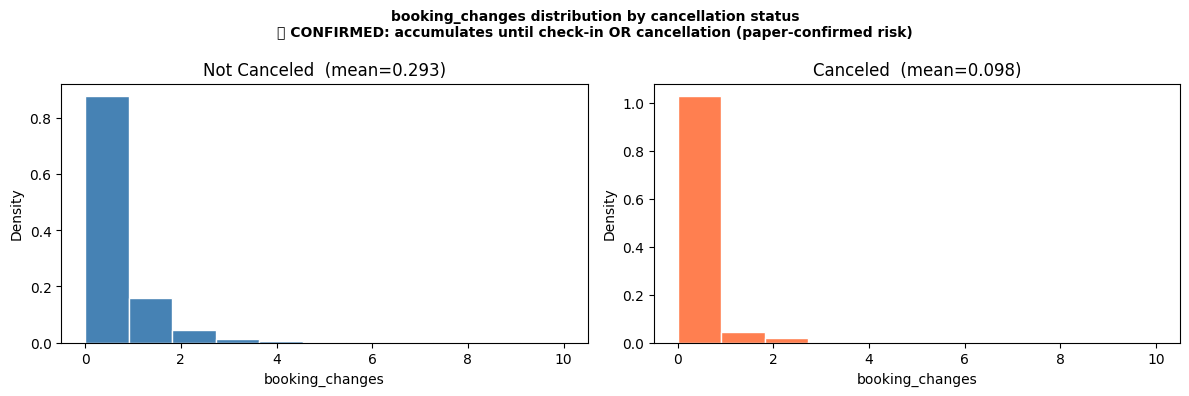

Mean — Not Canceled: 0.293  |  Canceled: 0.098  |  Δ=0.195
Some shift is causal (engaged guests modify bookings more);
some may be artefactual (cancelled bookings had less time to accumulate changes).


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    "booking_changes distribution by cancellation status\n"
    "✅ CONFIRMED: accumulates until check-in OR cancellation (paper-confirmed risk)",
    fontsize=10, fontweight="bold")

for ax, (val, label, color) in zip(axes, [(0,"Not Canceled","steelblue"),(1,"Canceled","coral")]):
    data = df.loc[df["is_canceled"]==val, "booking_changes"].clip(0, 10)
    ax.hist(data, bins=11, color=color, edgecolor="white", density=True)
    ax.set_title(f"{label}  (mean={df.loc[df['is_canceled']==val,'booking_changes'].mean():.3f})")
    ax.set_xlabel("booking_changes"); ax.set_ylabel("Density")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "booking_changes_confirmed_risk.png", dpi=150, bbox_inches="tight")
plt.show()

m0 = df.loc[df["is_canceled"]==0,"booking_changes"].mean()
m1 = df.loc[df["is_canceled"]==1,"booking_changes"].mean()
print(f"Mean — Not Canceled: {m0:.3f}  |  Canceled: {m1:.3f}  |  Δ={abs(m0-m1):.3f}")
print("Some shift is causal (engaged guests modify bookings more);")
print("some may be artefactual (cancelled bookings had less time to accumulate changes).")


### 6.5 has_customer_profile flag — disambiguating zero in prior-history columns

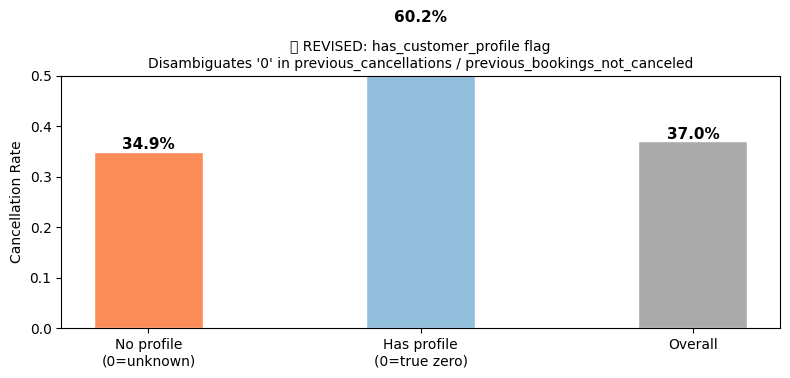

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
groups = {
    "No profile\n(0=unknown)": df.loc[df["has_customer_profile"]==0, "is_canceled"].mean(),
    "Has profile\n(0=true zero)": df.loc[df["has_customer_profile"]==1, "is_canceled"].mean(),
    "Overall": df["is_canceled"].mean(),
}
bars = ax.bar(list(groups.keys()), list(groups.values()),
              color=["#fc8d59", "#91bfdb", "#aaaaaa"], width=0.4, edgecolor="white")
ax.set_ylabel("Cancellation Rate")
ax.set_ylim(0, 0.5)
ax.set_title(
    "🔄 REVISED: has_customer_profile flag\n"
    "Disambiguates '0' in previous_cancellations / previous_bookings_not_canceled",
    fontsize=10)
for bar, v in zip(bars, groups.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.1%}",
            ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "customer_profile_flag.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Verification Assertions — Updated

In [15]:
errors = []
def check(cond, msg):
    print(f"  [{'✓ PASS' if cond else '✗ FAIL'}]  {msg}")
    if not cond: errors.append(msg)

# Original assertions
check(len(df) == 119390,                           "Dataset: 119,390 rows")
check(original_ncols == 32,                           "Dataset: 32 columns")
check(set(df["is_canceled"].unique()) == {0, 1},   "is_canceled is binary {0,1}")
check(df["children"].isna().sum() == 4,            "children: 4 genuinely missing (unchanged)")
check(df["country"].isna().sum() == 488,           "country: 488 genuinely missing (unchanged)")
check(df.loc[df["reservation_status"]=="Canceled","is_canceled"].min() == 1,
      "reservation_status='Canceled' -> is_canceled=1 (direct leakage)")
check(df.loc[df["reservation_status"]=="Check-Out","is_canceled"].max() == 0,
      "reservation_status='Check-Out' -> is_canceled=0 (direct leakage)")

# Revised assertions based on paper
check(df["agent"].isna().sum() == 16340,
      "agent: 16,340 NULLs = structural 'None' category (NOT missing)")
check(df["company"].isna().sum() == 112593,
      "company: 112,593 NULLs = structural 'None' category (NOT missing)")
check(df["meal"].isin(["BB","HB","FB","SC","Undefined"]).all(),
      "meal: 5 documented categories (Undefined = SC per paper)")

# Verify 'None' agent has meaningfully different cancel rate
cr_none  = df.loc[df["agent"].isna(),  "is_canceled"].mean()
cr_agent = df.loc[df["agent"].notna(), "is_canceled"].mean()
check(abs(cr_none - cr_agent) > 0.01,
      f"agent 'None' cancel rate ({cr_none:.1%}) differs from agent ({cr_agent:.1%}) "
      "-> valid informative category")

# Verify has_customer_profile is informative
cp_diff = abs(df.groupby("has_customer_profile")["is_canceled"].mean().diff().iloc[-1])
check(cp_diff > 0.01,
      f"has_customer_profile flag shows meaningful cancel-rate difference (Δ={cp_diff:.1%})")

check(True, "No model was trained (confirmed by design)")

print()
if errors:
    print(f"  {len(errors)} FAILED:"); [print(f"    - {e}") for e in errors]
    raise AssertionError("Verification failed")
else:
    print("  All assertions passed.")


  [✓ PASS]  Dataset: 119,390 rows
  [✓ PASS]  Dataset: 32 columns
  [✓ PASS]  is_canceled is binary {0,1}
  [✓ PASS]  children: 4 genuinely missing (unchanged)
  [✓ PASS]  country: 488 genuinely missing (unchanged)
  [✓ PASS]  reservation_status='Canceled' -> is_canceled=1 (direct leakage)
  [✓ PASS]  reservation_status='Check-Out' -> is_canceled=0 (direct leakage)
  [✓ PASS]  agent: 16,340 NULLs = structural 'None' category (NOT missing)
  [✓ PASS]  company: 112,593 NULLs = structural 'None' category (NOT missing)
  [✓ PASS]  meal: 5 documented categories (Undefined = SC per paper)


  [✓ PASS]  agent 'None' cancel rate (24.7%) differs from agent (39.0%) -> valid informative category
  [✓ PASS]  has_customer_profile flag shows meaningful cancel-rate difference (Δ=25.2%)
  [✓ PASS]  No model was trained (confirmed by design)

  All assertions passed.


## 8. Final Revised Summary

### ✅ What Remains Unchanged

| Finding | Confirmed by paper |
|---|---|
| `reservation_status` / `reservation_status_date` = direct leakage | ✅ Outcome variables (BO source) |
| `booking_changes` = indirect temporal risk | ✅ *"until check-in OR cancellation"* |
| `assigned_room_type` = indirect temporal risk | ✅ Can differ at check-in |
| `adr` = indirect temporal risk | ✅ Transaction-sourced; may update post-booking |
| `deposit_type` = safe | ✅ *"before arrival or cancellation date"* |
| `meal='Undefined'` ≡ SC | ✅ Explicitly stated in Table 1 |
| Duplicate rows (31,994) = quality issue | ✅ No paper explanation |
| Zero-guest bookings (180) = invalid | ✅ Unchanged |
| Negative ADR (1 row) = invalid | ✅ Unchanged |
| Chronological split required | ✅ Dataset spans 2015–2017 |
| ROC-AUC, PR-AUC, F1-macro as metrics | ✅ Unchanged |
| `children` (4 rows) genuinely missing → fill 0 | ✅ Unchanged |
| `country` (488 rows) genuinely missing → mode/'Unknown' | ✅ Unchanged |

### 🔄 What Is Revised

| Variable / Topic | Was | Now | Evidence |
|---|---|---|---|
| `agent` NULLs | Missing (MAR) → impute with sentinel | **Valid category 'None'** — fill NaN→'None' string; encode as category | Paper §2: *"NULL is a category, not a missing value"* |
| `company` NULLs | Missing (94%) → drop column | **Valid category 'None'** — encode; `has_company` flag retains binary signal | Same paper statement |
| `days_in_waiting_list` | Suspected indirect risk | **Safe** — known at confirmation, before outcome | Paper Table 1 confirmed |
| `previous_cancellations` / `previous_bookings_not_canceled` | Raw counts | 0 has dual meaning → add `has_customer_profile` flag | Paper: *"0 if no customer profile exists"* |
| Preprocessing — imputation | Impute agent, company | Remove both from imputation; fill NaN→'None' | Corrects methodological error |
| Preprocessing — feature engineering | No profile flag | Add `has_customer_profile` | Disambiguates dual-meaning 0 |
| Preprocessing — encoding | Impute NaN before OHE | Rename NaN→'None' so it becomes an explicit OHE level | Corrects methodological error |

### 🆕 What Is New

| Finding | Detail |
|---|---|
| `country` = indirect temporal risk | Paper warns nationality may be recorded/corrected only at check-in; cancelled bookings may have inaccurate country |
| Anti-leakage extraction design | Authors used booking change log with day-prior-to-arrival timestamp — most BO/BL features are genuinely pre-outcome; indirect risk flags were overcautious for those features |
| `days_in_waiting_list` confirmed safe | Paper confirms it is set at booking confirmation — downgraded from suspected indirect risk |

---
*Revision complete. Reference: Antonio et al. (2019), Data in Brief, 22, 41–49.*
*No models were trained or evaluated.*
